<a href="https://colab.research.google.com/github/billalsohail/ML4MC/blob/main/Coulomb_matrix_representation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Mount you G-drive so all the files are in one place

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
#Load modules and data

! pip install dscribe
import numpy as np
import math, random
import matplotlib.pyplot as plt
import pandas as pd
import json
import seaborn as sns
from scipy.sparse import load_npz
from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import GridSearchCV
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from dscribe.descriptors import CoulombMatrix 
from ase import *
from ase.build import molecule
from ase.io import read, write
import io


In [3]:
!cp '/content/drive/MyDrive/ColabNotebooks/Data/helpers.py' .

from helpers import get_level  # needs to go here as wont have been downloaded earlier in

def xyz_to_atoms(xyz):
    f = io.StringIO()
    f.write(xyz)
    f.seek(0)  # had to add this in otherwise wont return to start of file once read in
    atoms = read(f, format="xyz")
    return atoms

print('Loading data...')
df = pd.read_json('/content/drive/MyDrive/ColabNotebooks/Data/df_5k.json', orient='split')

print('Generating `ase.Atoms` objects...')
df['atoms'] = df['xyz_pbe_relaxed'].apply(xyz_to_atoms)

print('Extracting HOMO, LUMO, BANDGAP from data...')
df['HOMO'] = df.apply(lambda row: get_level(row, level_type='HOMO', subset='GOWO_at_PBE0_cbs'), axis=1)
df['LUMO'] = df.apply(lambda row: get_level(row, level_type='LUMO', subset='GOWO_at_PBE0_cbs'), axis=1)
df['BG'] = df['LUMO'] - df['HOMO']
print('~ 2300 molecules do not have LUMO energy levels for this or any other `GOWO` level of theory.')

# print('Splitting data set...')
# train, test = train_test_split(df, test_size=0.2, random_state=20210817)
# train_atoms, test_atoms = train['atoms'].to_list(), test['atoms'].to_list()

print('Data Processing Complete')
print('#', '-'*119)

Loading data...
Generating `ase.Atoms` objects...
Extracting HOMO, LUMO, BANDGAP from data...
err FOVWES
err FOWGIH
err FOYJUZ
err FUNBUL
err FUPZAR
err FUXFAG
err GANSAQ
err GAQCEI
err NUFRUB
err GEPHEO
err GERGOB
err GETBUD
err GEVDAN
err GEYQAC
err GIDQAN
err GIMPUO
err GISBOA
err NUNJAH
err NUNJEL
err NUNKEM
err GODBUW
err NUQCIM
err WEBWUV
err GUCLIA
err GUMBEV
err HACGAT
err HADSEM
err HANBEF
err HANNEP
err LUXPAW
err HAVSIH
err HAWTEF
err HAXWAG
err HAZFNO
err HEHQIW
err HEJGOS
err HELCEG
err HEMLIU
err HEQMOG
err HERKEV
err HESKOF01
err HEVNAX
err HEVNIF
err HEWJIE
err OBOYOV
err HIFYAY
err HIJCEI
err HINREB
err HINTAZ
err WUJHOY
err HIVCOF
err HIXLOP
err WULZIM
err HMNCXC01
err HMSPYR
err HMTCSP10
err HOFJOB
err HOHGER
err HOHLAR
err HOJVUX
err HOKZEN
err HOQHUQ
err HORNUY
err OCAYUN
err HUHJUQ
err HUXKOB
err IFEFII
err IFOQIE
err LUZKEX
err IJEDAC
err IJENIU
err IJIWIH
err ILIGAM
err ILOCAN
err LOFBUD
err XILQUE
err IMINEY
err IMSTXP10
err IQAHUD
err XINWUN
err IROQOV
err IRU

Inspect the dataframe 

In [4]:
col_names = list(df.columns)
print(col_names)
df.head(3)
print(df.shape)

['refcode_csd', 'canonical_smiles', 'inchi', 'number_of_atoms', 'xyz_pbe_relaxed', 'energies_occ_pbe', 'energies_occ_pbe0_vac_tier2', 'energies_occ_pbe0_water', 'energies_occ_pbe0_vac_tzvp', 'energies_occ_pbe0_vac_qzvp', 'energies_occ_gw_tzvp', 'energies_occ_gw_qzvp', 'cbs_occ_gw', 'energies_unocc_pbe', 'energies_unocc_pbe0_vac_tier2', 'energies_unocc_pbe0_water', 'energies_unocc_pbe0_vac_tzvp', 'energies_unocc_pbe0_vac_qzvp', 'energies_unocc_gw_tzvp', 'energies_unocc_gw_qzvp', 'cbs_unocc_gw', 'total_energy_pbe', 'total_energy_pbe0_vac_tier2', 'total_energy_pbe0_water', 'total_energy_pbe0_vac_tzvp', 'total_energy_pbe0_vac_qzvp', 'hirshfeld_pbe', 'hirshfeld_pbe0_vac_tier2', 'hirshfeld_pbe0_water', 'atoms', 'HOMO', 'LUMO', 'BG']
(5239, 33)


Begin with looking at just one example at random from the dataframe

In [5]:

#Lets look at a random molecule represented with a Coulomb matrix 
y = df['xyz_pbe_relaxed'].shape[0]
# print(df['xyz_pbe_relaxed'])
print(y)

rand_mol = random.randint(0, y)
print(df['xyz_pbe_relaxed'].iloc[rand_mol])
mol_of_choice = df['xyz_pbe_relaxed'].iloc[rand_mol]


5239
28

C      46.06521014      44.62163130      50.64572123 
C      45.08938872      43.98446991      49.86677784 
H      44.82511893      44.38098203      48.88889901 
C      44.46447864      42.84146249      50.35012617 
H      43.70645392      42.34230581      49.74916503 
C      46.40612653      46.34033254      49.03685893 
C      46.89819175      46.66784401      46.68371190 
H      47.47438156      46.43718172      45.79039930 
C      47.15912102      46.02969339      47.91056847 
O      46.73982559      45.74277432      50.25971310 
C      44.13421908      41.13676069      52.07550785 
C      46.14787085      42.45653716      53.66909672 
C      44.79112738      42.30899237      51.60575105 
C      45.78153184      42.96139449      52.38502405 
C      46.41000365      44.11018057      51.90170931 
H      47.16950572      44.61392292      52.49570783 
N      43.58078122      40.17674757      52.43560291 
N      46.46183347      42.06218573      54.71854613 
C      45.36871851 

Visually present the random molecule of choice in the CM representation

(28, 28)


<Figure size 432x288 with 0 Axes>

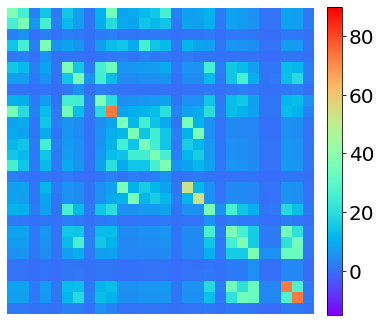

In [6]:
cm_desc = CoulombMatrix(n_atoms_max=28, permutation='none', flatten=False)
mol = df['atoms'].iloc[rand_mol]

matrix = cm_desc.create(mol)
print(matrix.shape)

#Lets have a look at our random molecule and visualise the CM
plt.figure()
plt.figure(figsize = (6,6))
plt.imshow(matrix, origin="upper", cmap='rainbow', vmin=-15, vmax=90, interpolation='nearest')
plt.colorbar(fraction=0.046, pad=0.04).ax.tick_params(labelsize=20)
plt.axis('off')
plt.show()

Last inspection of the data frame is to look at the distribution of our labels - in this case these are the HOMO values

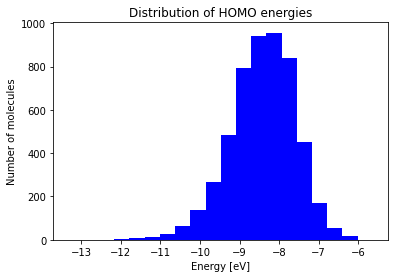

Mean value of HOMO energies in OE62 dataset: -8.42 eV


In [7]:
plt.hist(df['HOMO'].values, bins=20, density=False, facecolor='blue')
plt.xlabel("Energy [eV]")
plt.ylabel("Number of molecules")
plt.title("Distribution of HOMO energies")
plt.show()

## mean value of distribution
print("Mean value of HOMO energies in OE62 dataset: %0.2f eV" %np.mean(df['HOMO'].values))

Perform the split of data

In [8]:
 train, test = train_test_split(df, test_size=0.2, random_state=20210817)
train_atoms, test_atoms = train['atoms'].to_list(), test['atoms'].to_list()

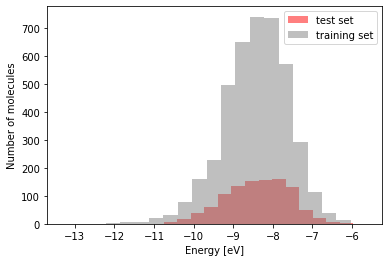

Mean value of HOMO energies in training set: -8.43 eV
Mean value of HOMO energies in test set: -8.39 eV


In [9]:
#Lets visualise the data for each split to see if it resembles each other


plt.hist(test['HOMO'].values, bins=20, density=False, alpha=0.5, facecolor='red', label='test set')
plt.hist(train['HOMO'].values, bins=20, density=False, alpha=0.5, facecolor='gray', label='training set')
plt.xlabel("Energy [eV]")
plt.ylabel("Number of molecules")
plt.legend()
plt.show()

## mean value of distributions
print("Mean value of HOMO energies in training set: %0.2f eV" %np.mean(train['HOMO'].values))
print("Mean value of HOMO energies in test set: %0.2f eV" %np.mean(test['HOMO'].values))

This is a simple model which works

In [10]:
atomic_numbers = df['atoms'].apply(lambda x: x.numbers)
unique_atomic_numbers = set([a for b in atomic_numbers for a in b])
max_num_atoms = atomic_numbers.apply(len).max()

print(unique_atomic_numbers)
print(max_num_atoms)

feature_calc = CoulombMatrix(n_atoms_max=max_num_atoms)
print('Generating features...')
X_train, X_test = (np.vstack([feature_calc.create(a) for a in d]) for d in (train_atoms, test_atoms))
print('Features generated.')


y_train = train['HOMO'].values  # extract target value from dataframe
y_test = test['HOMO'].values
y_ave = np.average(y_train)

#normalise data
# y_train_tf = (y_train-y_ave)/y_ave
# y_test_tf = (y_test-y_ave)/y_ave


# # split the training data again intor training and cross validation sets
# X_tr, X_cv, y_tr, y_cv = train_test_split(X_train, y_train_tf, test_size=0.2, random_state=1)

# model = KernelRidge(kernel='rbf', alpha=0.01, gamma=0.01) 
# model.fit(X_tr, y_tr)

# y_pred_tr = model.predict(X_tr)
# y_pred_cv = model.predict(X_cv)
# y_pred_ts = model.predict(X_test)

# y_pred_tr = (y_pred_tr * y_ave)+y_ave
# y_pred_cv = (y_pred_cv * y_ave)+y_ave
# y_pred_ts = (y_pred_ts * y_ave)+y_ave


# for s, pred, ref in zip(('train', 'cv', 'test'), (y_pred_tr, y_pred_cv, y_pred_ts), (y_tr, y_cv,y_test)):
#   mse = mean_squared_error(ref, pred)
#   r2 = r2_score(ref, pred)

#   print(F'{s} : mse={mse:.3f}, r2={r2:.3f}')



{1, 34, 35, 33, 5, 6, 7, 8, 9, 3, 14, 15, 16, 17, 53}
100
Generating features...
Features generated.


In [11]:
# plt.plot(y_pred_ts, y_test,lw=0.0,marker='.')
# #plt.ylim(-13,-6)
# #plt.xlim(-13,-6)
# plt.xlabel('predicted homo energy in test set')
# plt.ylabel('reference homo energy')
# plt.title('G0W0 HOMO, KRR-rbf with CM, alpha=0.01, gamma=0.01')
# plt.show()

In [13]:
# set up grids for alpha and gamma hyperparameters. 
# first value: lower bound; second value: upper bound; 
# third value: number of points to evaluate (here set to '3' --> '-2', '-1' and '0' are evaluated)
# --> make sure to change third value as well when changing the bounds!
alpha = np.logspace(-5, -2, 4)
gamma = np.logspace(-5, -2, 4)


cv_number = 5 ## choose into how many parts training set is divided for cross-validation
kernel = 'rbf' # select kernel function here ('rbf': Gaussian kernel, 'laplacian': Laplacian kernel)
scoring_function = 'neg_mean_absolute_error' # it is called "negative" because scikit-learn interprets
                                             # highest scoring value as best, but we want small errors

## define settings for grid search routine in scikit-learn with above defined grids as input

grid_search = GridSearchCV(KernelRidge(),  #machine learning method (KRR here)
                           [{'kernel':[kernel],'alpha': alpha, 'gamma': gamma}], 
                           cv = cv_number, 
                           scoring = scoring_function, n_jobs=2,
                           verbose=1000)  ## produces detailed output statements of grid search 
                                          # routine so we can see what is computed
    
# call the fit function in scikit-learn which fits the Coulomb matrices in the training set 
# to their corresponding HOMO energies.

from datetime import datetime
start = datetime.now()

grid_search.fit(X_train, y_train)


finish = datetime.now()
total_time = finish - start 
print("It took how long?", total_time)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:   15.1s
[Parallel(n_jobs=2)]: Done   2 tasks      | elapsed:   15.6s
[Parallel(n_jobs=2)]: Done   3 tasks      | elapsed:   27.8s
[Parallel(n_jobs=2)]: Done   4 tasks      | elapsed:   28.4s
[Parallel(n_jobs=2)]: Done   5 tasks      | elapsed:   40.3s
[Parallel(n_jobs=2)]: Done   6 tasks      | elapsed:   41.1s
[Parallel(n_jobs=2)]: Done   7 tasks      | elapsed:   53.1s
[Parallel(n_jobs=2)]: Done   8 tasks      | elapsed:   54.0s
[Parallel(n_jobs=2)]: Done   9 tasks      | elapsed:  1.1min
[Parallel(n_jobs=2)]: Done  10 tasks      | elapsed:  1.1min
[Parallel(n_jobs=2)]: Done  11 tasks      | elapsed:  1.3min
[Parallel(n_jobs=2)]: Done  12 tasks      | elapsed:  1.3min
[Parallel(n_jobs=2)]: Done  13 tasks      | elapsed:  1.5min
[Parallel(n_jobs=2)]: Done  14 tasks      | elapsed:  1.6min
[Parallel(

In [14]:
means = grid_search.cv_results_['mean_test_score']
stds = grid_search.cv_results_['std_test_score']
for mean, std, params in zip(-means, stds, grid_search.cv_results_['params']):
    print("%0.3f (+/-%0.03f) for %r" % (mean, std * 2, params))

0.709 (+/-0.075) for {'alpha': 1e-05, 'gamma': 1e-05, 'kernel': 'rbf'}
4.193 (+/-0.334) for {'alpha': 1e-05, 'gamma': 0.0001, 'kernel': 'rbf'}
8.424 (+/-0.066) for {'alpha': 1e-05, 'gamma': 0.001, 'kernel': 'rbf'}
8.429 (+/-0.065) for {'alpha': 1e-05, 'gamma': 0.01, 'kernel': 'rbf'}
0.709 (+/-0.075) for {'alpha': 0.0001, 'gamma': 1e-05, 'kernel': 'rbf'}
4.193 (+/-0.334) for {'alpha': 0.0001, 'gamma': 0.0001, 'kernel': 'rbf'}
8.424 (+/-0.066) for {'alpha': 0.0001, 'gamma': 0.001, 'kernel': 'rbf'}
8.429 (+/-0.065) for {'alpha': 0.0001, 'gamma': 0.01, 'kernel': 'rbf'}
0.707 (+/-0.076) for {'alpha': 0.001, 'gamma': 1e-05, 'kernel': 'rbf'}
4.194 (+/-0.334) for {'alpha': 0.001, 'gamma': 0.0001, 'kernel': 'rbf'}
8.424 (+/-0.066) for {'alpha': 0.001, 'gamma': 0.001, 'kernel': 'rbf'}
8.429 (+/-0.065) for {'alpha': 0.001, 'gamma': 0.01, 'kernel': 'rbf'}
0.700 (+/-0.078) for {'alpha': 0.01, 'gamma': 1e-05, 'kernel': 'rbf'}
4.200 (+/-0.334) for {'alpha': 0.01, 'gamma': 0.0001, 'kernel': 'rbf'}
8.4

The best combinations of parameters are {'alpha': 0.01, 'gamma': 1e-05, 'kernel': 'rbf'} with a score of 0.700 eV on the validation set.


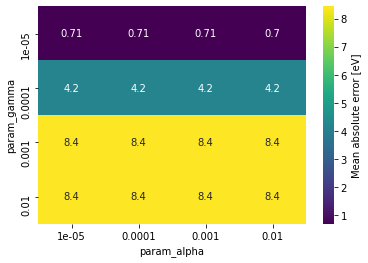

In [19]:
results = pd.DataFrame(grid_search.cv_results_)
#pd.DataFrame(grid_search.cv_results_)

pvt = pd.pivot_table(results, values='mean_test_score', 
                     index='param_gamma', columns='param_alpha')
heatmap = sns.heatmap(-pvt, annot=True, cmap='viridis', cbar_kws={'label': "Mean absolute error [eV]"})
figure = heatmap.get_figure()
plt.savefig("/content/drive/MyDrive/ColabNotebooks/"+str("gaussian2.png"), dpi=400)


print("The best combinations of parameters are %s with a score of %0.3f eV on the validation set."
      % (grid_search.best_params_, -grid_search.best_score_))

In [45]:

type(grid_search.best_params_)
for i in grid_search.best_params_.values():
  print(i)


0.01
1e-05
laplacian


Mean absolute error on test set: 0.754 eV
R^2 score on test set: -2.136


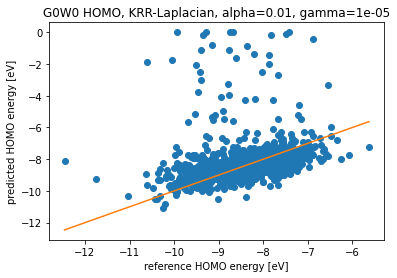

In [17]:
# predicted HOMO energies for all test molecules

y_pred = grid_search.predict(X_test) # scikit-learn automatically takes the best combination
                                     # of hyperparameters from grid search

print("Mean absolute error on test set: %0.3f eV" %(np.abs(y_pred-y_test)).mean())

# do the regression plot
plt.plot(y_test, y_pred, 'o')
plt.plot([np.min(y_test),np.max(y_test)], [np.min(y_test),np.max(y_test)], '-')
plt.xlabel('reference HOMO energy [eV]')
plt.ylabel('predicted HOMO energy [eV]')
lst_best_params= list(grid_search.best_params_.values())
plt.title("G0W0 HOMO, KRR-Laplacian, alpha=0.01, gamma=1e-05")
plt.savefig("/content/drive/MyDrive/ColabNotebooks/"+str("gaussian.png"), dpi=400)
print("R^2 score on test set: %.3f" % r2_score(y_test, y_pred))

Generate CM representation in the dataframe for all `atom objects`

In [18]:
cm_desc = CoulombMatrix(n_atoms_max=120, permutation='none', flatten=False)
df['CM_rep'] = df['atoms'].apply(cm_desc.create)
